In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.insert(0, '../src')
from kl import load_kl_records

kl_path = '../data/kl_seed42_embd16_layer1_blk16_interval10.npz'
records = load_kl_records(kl_path)
for order, (steps, vals) in sorted(records.items()):
    print(f"order={order}: {len(steps)} entries, steps {steps[0]}..{steps[-1]}, KL range [{vals.min():.4f}, {vals.max():.4f}]")

order=1: 100 entries, steps 0..990, KL range [0.2497, 0.6910]
order=2: 100 entries, steps 0..990, KL range [0.1296, 1.7162]
order=3: 100 entries, steps 0..990, KL range [0.4513, 6.0340]
order=4: 100 entries, steps 0..990, KL range [0.9096, 10.4532]


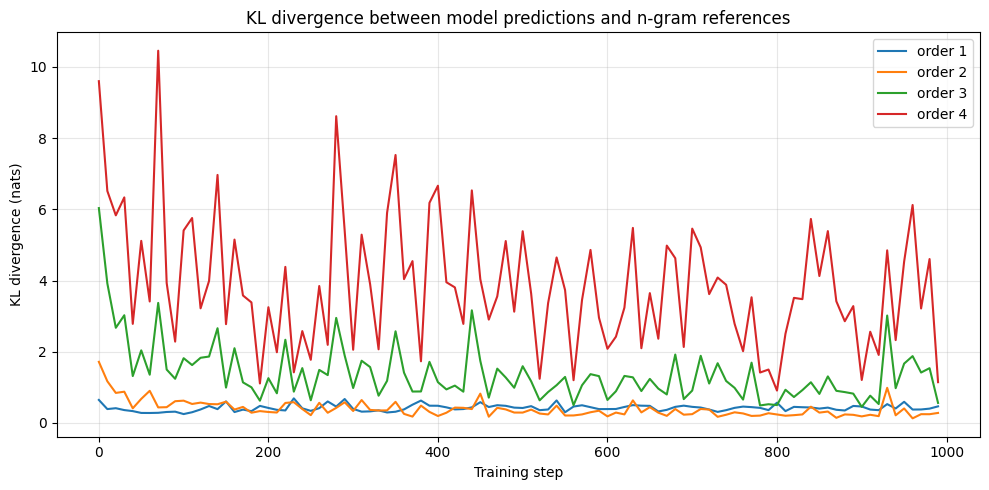

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

for order, (steps, vals) in sorted(records.items()):
    ax.plot(steps, vals, label=f'order {order}')

ax.set_xlabel('Training step')
ax.set_ylabel('KL divergence (nats)')
ax.set_title('KL divergence between model predictions and n-gram references')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
from ngrams import load_ngrams

ngrams_path = '../data/ngrams.npz'
ngrams = load_ngrams(ngrams_path)

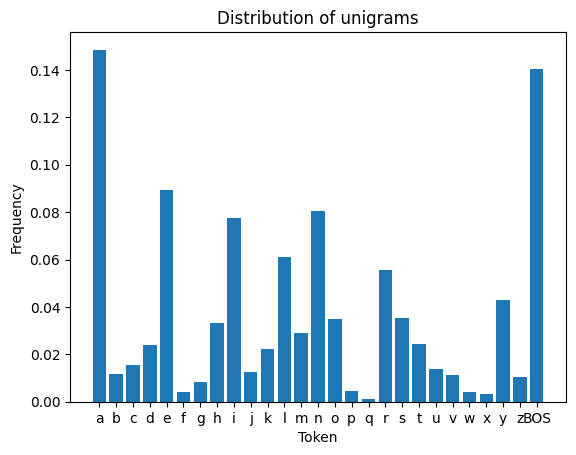

In [6]:
tokens = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'BOS']
plt.bar(tokens, ngrams[1][0]);
plt.ylabel("Frequency");
plt.xlabel("Token");
plt.title("Distribution of unigrams");

In [7]:
def bigram_distribution(token):
    """Return P(next_char | token) as a numpy array over all 27 tokens."""
    if token not in tokens:
        raise ValueError(f"'{token}' is not a valid token. Must be one of: {tokens}")
    idx = tokens.index(token)
    probs, seen = ngrams[2]
    if not seen[idx]:
        raise ValueError(f"'{token}' was never seen as a context in the training data.")
    return probs[idx]  # shape (27,), sums to 1.0


# example
# dist = bigram_distribution('a')
# for tok, p in zip(tokens, dist):
#     if p > 0:
#         print(f"P(next='{tok}' | 'a') = {p:.4f}")

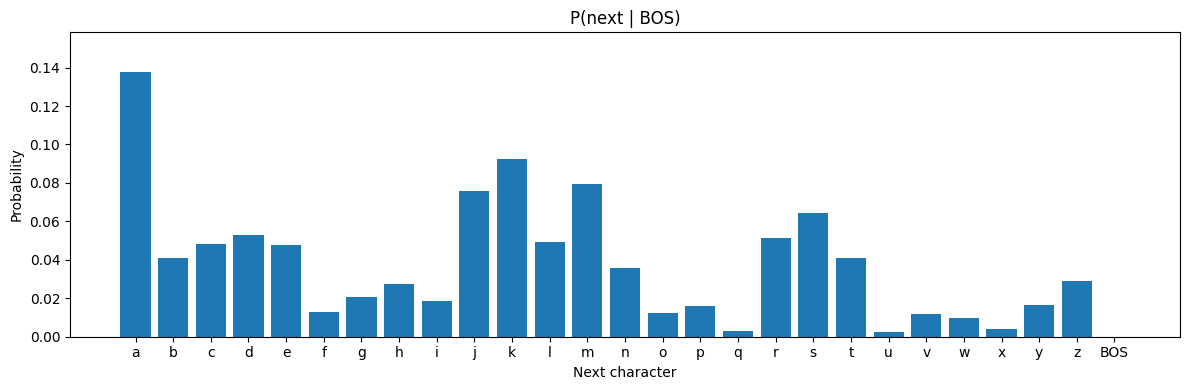

In [8]:
def plot_bigram_distribution(token):
    dist = bigram_distribution(token)
    label = 'BOS' if token == 'BOS' else f"'{token}'"

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(tokens, dist)
    ax.set_xlabel('Next character')
    ax.set_ylabel('Probability')
    ax.set_title(f'P(next | {label})')
    ax.set_ylim(0, max(dist) * 1.15)
    plt.tight_layout()
    plt.show()

plot_bigram_distribution('BOS')